In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/ramezfawzy/ar-dataset/ALHD_Main.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(405456, 8)
['text', 'label', 'generator', 'source', 'category', 'subcategory', 'token_count', 'document_id']
                                                text  label  generator source  \
0  تم رصد احتفالات هائلة في شوارع بطرابلس، بمجرد ...      1  GPT-3.5-T   ANAD   
1  أعلن تويتر اليوم عن تحسينات جديدة تهدف إلى تحس...      1  GPT-3.5-T   ANAD   
2  تم مؤخرا كشف مصدر موثوق في صنعاء عن مخطط إجرام...      1  GPT-3.5-T   ANAD   
3  تم تأكيد جاهزية ملعب النادي الأهلي لـ "الكلاسي...      1  GPT-3.5-T   ANAD   
4  شركة بلاك بيري الكندية تعلن عن اتمام صفقة استح...      1  GPT-3.5-T   ANAD   

               category subcategory  token_count  document_id  
0         alarabiya.net    Politics          188        34001  
1           aitnews.com  Technology          227        34002  
2        alwatan.com.sa    Politics          340        34003  
3  akhbaar24.argaam.com       Sport          203        34004  
4           aitnews.com  Technology          179        34005  


In [2]:
# استكشاف الداتا
print("=== Shape ===")
print(df.shape)

print("\n=== Label Distribution ===")
print(df['label'].value_counts())

print("\n=== Generator Distribution ===")
print(df['generator'].value_counts())

print("\n=== Source Distribution ===")
print(df['source'].value_counts())

print("\n=== Category Distribution ===")
print(df['category'].value_counts())

print("\n=== Null Values ===")
print(df.isnull().sum())

print("\n=== Token Count Stats ===")
print(df['token_count'].describe())

=== Shape ===
(405456, 8)

=== Label Distribution ===
label
1    304092
0    101364
Name: count, dtype: int64

=== Generator Distribution ===
generator
GPT-3.5-T       101364
GEMINI-2.5-F    101364
COMMAND-R       101364
HUMAN           101364
Name: count, dtype: int64

=== Source Distribution ===
source
ANAD     67576
BRAD     67576
HARD     67576
MASC     67576
MDAT     67576
SANAD    67576
Name: count, dtype: int64

=== Category Distribution ===
category
Twitter                 135152
Booking.com              67576
Goodreads                67576
Akhbarona                27068
Arabiya                  24436
alarabiya.net            17824
akhbaar24.argaam.com     17532
Khaleej                  16072
aleqt.com                13240
ienalwatan.com            5280
aitnews.com               5248
alwatan.com.sa            4428
almuraba.net              1464
aawsat.com                1332
alsyahaalarabia.com        764
ksa.motory.com:ar          260
bbc.com:arabic             172
neprass.org

In [3]:
# نشوف التوزيع بالتفصيل
print("=== Overall Balance ===")
print(df['label'].value_counts())
print(f"\nRatio: {304092/101364:.1f}x more AI than Human")

print("\n=== Balance per Source ===")
print(df.groupby(['source', 'label']).size().unstack())

print("\n=== Balance per Category (Top 5) ===")
print(df.groupby(['category', 'label']).size().unstack().head(10))


=== Overall Balance ===
label
1    304092
0    101364
Name: count, dtype: int64

Ratio: 3.0x more AI than Human

=== Balance per Source ===
label       0      1
source              
ANAD    16894  50682
BRAD    16894  50682
HARD    16894  50682
MASC    16894  50682
MDAT    16894  50682
SANAD   16894  50682

=== Balance per Category (Top 5) ===
label                     0       1
category                           
Akhbarona              6767   20301
Arabiya                6109   18327
Booking.com           16894   50682
Goodreads             16894   50682
Khaleej                4018   12054
Twitter               33788  101364
aawsat.com              333     999
aitnews.com            1312    3936
akhbaar24.argaam.com   4383   13149
alarabiya.net          4456   13368


In [4]:
import pandas as pd
import re

In [5]:
# Load Data
df = pd.read_csv('/kaggle/input/datasets/ramezfawzy/ar-dataset/ALHD_Main.csv')
print(f"Shape: {df.shape}")
print(df['label'].value_counts())

Shape: (405456, 8)
label
1    304092
0    101364
Name: count, dtype: int64


In [6]:
print(df.describe())

print(df['text'].describe())

df['text_len'] = df['text'].str.len()
print(df['text_len'].describe())

               label    token_count    document_id
count  405456.000000  405456.000000  405456.000000
mean        0.750000     214.511000   51001.950643
std         0.433013     280.668234   29445.315224
min         0.000000       1.000000       1.000000
25%         0.750000      43.000000   25506.750000
50%         1.000000     147.000000   51000.500000
75%         1.000000     311.000000   76504.250000
max         1.000000   88469.000000  102000.000000
count                405456
unique               405445
top       GENERATION_FAILED
freq                      4
Name: text, dtype: object
count    405456.000000
mean        701.514653
std         803.578467
min           3.000000
25%         136.000000
50%         480.000000
75%        1030.000000
max       89791.000000
Name: text_len, dtype: float64


In [7]:
df[df["text"]== "GENERATION_FAILED"].sum()

text           GENERATION_FAILEDGENERATION_FAILEDGENERATION_F...
label                                                          4
generator       GEMINI-2.5-FGEMINI-2.5-FGEMINI-2.5-FGEMINI-2.5-F
source                                          BRADHARDMASCMDAT
category                      GoodreadsBooking.comTwitterTwitter
subcategory                      BookReviewHotelReviewTweetTweet
token_count                                                   36
document_id                                               228662
text_len                                                      68
dtype: object

In [8]:
df.drop(df[df["text"] == "GENERATION_FAILED"].index, inplace=True)

In [9]:
df[df["text"]== "GENERATION_FAILED"].sum()

text           0
label          0
generator      0
source         0
category       0
subcategory    0
token_count    0
document_id    0
text_len       0
dtype: object

In [10]:
df.isna().sum()

text           0
label          0
generator      0
source         0
category       0
subcategory    0
token_count    0
document_id    0
text_len       0
dtype: int64

In [11]:
df = df[df["text"].str.split().str.len() > 20]

In [12]:
print(df.describe())

print(df['text'].describe())

df['text_len'] = df['text'].str.len()
print(df['text_len'].describe())

               label    token_count    document_id       text_len
count  315711.000000  315711.000000  315711.000000  315711.000000
mean        0.805255     269.941548   50991.133771     883.596226
std         0.396005     294.772382   28586.265372     822.733776
min         0.000000      22.000000       1.000000      73.000000
25%         1.000000     101.000000   27435.500000     325.000000
50%         1.000000     216.000000   47306.000000     717.000000
75%         1.000000     357.000000   76311.500000    1181.000000
max         1.000000   88469.000000  102000.000000   89791.000000
count                                                315711
unique                                               315711
top       سيرينا وليامز تعلن خطبتها لمؤسس موقع Reddit\n\...
freq                                                      1
Name: text, dtype: object
count    315711.000000
mean        883.596226
std         822.733776
min          73.000000
25%         325.000000
50%         717.000000
75

In [16]:
from datasets import load_dataset

print("Loading Arabic Wikipedia (New Version)...")

# 1. Loading data using the new path to avoid RuntimeError
# Using "wikimedia/wikipedia" instead of "wikipedia"
wiki_ar = load_dataset("wikimedia/wikipedia", "20231101.ar", split="train")

# 2. Filtering: Keeping articles with length > 1500 characters to ensure "rich" text
print("Filtering long articles...")
long_wiki = wiki_ar.filter(lambda x: len(x["text"]) > 1500)

# 3. Function to split articles into chunks
# Each chunk is approximately 400 words (to fit RoBERTa's 512 tokens)
import random

def chunk_text_random(batch):
    all_chunks = []
    for text in batch["text"]:
        words = text.split()
        i = 0
        while i < len(words):
            # نختار طول عشوائي للـ Chunk الحالية
            chunk_size = random.randint(150, 450)
            
            chunk = " ".join(words[i : i + chunk_size])
            
            # نضمن إن الـ Chunk مش قصيرة زيادة عن اللزوم (أقل من 500 حرف مثلاً)
            if len(chunk) > 500:
                all_chunks.append(chunk)
            
            i += chunk_size
            
    return {"text": all_chunks}
    
# 4. Executing Chunking on the first 70,000 articles
print("Splitting articles into long paragraphs (Chunking)...")
processed_wiki = long_wiki.select(range(70000)).map(
    chunk_text_random, 
    batched=True, 
    remove_columns=wiki_ar.column_names
)

# 5. Adding Label 0 to all resulting chunks (Human Class)
print(f"Preparing final samples (Available samples: {len(processed_wiki)})...")
final_human_dataset = processed_wiki.map(lambda x: {"label": 0})

print(f"Congratulations! You now have {len(final_human_dataset)} long human samples.")

Loading Arabic Wikipedia (New Version)...


README.md: 0.00B [00:00, ?B/s]

20231101.ar/train-00000-of-00007.parquet:   0%|          | 0.00/408M [00:00<?, ?B/s]

20231101.ar/train-00001-of-00007.parquet:   0%|          | 0.00/172M [00:00<?, ?B/s]

20231101.ar/train-00002-of-00007.parquet:   0%|          | 0.00/145M [00:00<?, ?B/s]

...

Splitting articles into long paragraphs (Chunking)...


Map:   0%|          | 0/70000 [00:00<?, ? examples/s]

Preparing final samples (Available samples: 261826)...


Map:   0%|          | 0/261826 [00:00<?, ? examples/s]

Congratulations! You now have 261826 long human samples.


In [20]:
# 6. Save the dataset to a CSV file
print("Saving dataset to CSV file...")

# Convert the Hugging Face dataset to a Pandas DataFrame first to use .to_csv()
final_human_df = final_human_dataset.to_pandas()
final_human_df.to_csv("wiki_human_chunks.csv", index=False)

print("Save successful! File is ready as: wiki_human_chunks.csv")

Saving dataset to CSV file...
Save successful! File is ready as: wiki_human_chunks.csv


In [21]:
import pandas as pd

print("--- شكل الداتا بعد التحويل ---")
print(final_human_df.shape)
print("\n--- أول 5 صفوف ---")
print(final_human_df.head())

# 3. فحص الـ Labels (لازم تطلع كلها 0 لأنها ويكيبيديا)
print("\n--- توزيع الـ Labels ---")
print(final_human_df['label'].value_counts())

--- شكل الداتا بعد التحويل ---
(261826, 2)

--- أول 5 صفوف ---
                                                text  label
0  الماء مادةٌ شفافةٌ عديمة اللون والرائحة، وهو ا...      0
1  زاوية الرابطة H-O-H مقدار 104.45°. تلك القيمة ...      0
2  قيمة الكثافة إلى البنية المفتوحة غير المتراصّة...      0
3  لذلك تخضع عادة إلى عملية إزالة للعسر. يمكن إجر...      0
4  مجرّة درب التبّانة؛ وذلك في كلّ من: الغلاف الج...      0

--- توزيع الـ Labels ---
label
0    261826
Name: count, dtype: int64


In [22]:
# 2. لو عايز إحصائيات عن النص نفسه (أكتر كلمة مكررة، عدد النصوص الفريدة، إلخ)
print(final_human_df['text'].describe())

# 3. نصيحة: عشان تشوف "طول النصوص" فعلياً، اعمل العمود ده الأول:
final_human_df['text_len'] = final_human_df['text'].str.len()
print(final_human_df['text_len'].describe())

count                                                261826
unique                                               261826
top       من ضحيته، كما في العراق. الإعفاء من جريمة الاغ...
freq                                                      1
Name: text, dtype: object
count    261826.000000
mean       1652.415100
std         556.107493
min         501.000000
25%        1197.000000
50%        1619.000000
75%        2091.000000
max       11216.000000
Name: text_len, dtype: float64


In [23]:
df.head()

,text,label,generator,source,category,subcategory,token_count,document_id,text_len
0,تم رصد احتفالات هائلة في شوارع بطرابلس، بمجرد ...,1,GPT-3.5-T,ANAD,alarabiya.net,Politics,188,34001,609
1,أعلن تويتر اليوم عن تحسينات جديدة تهدف إلى تحس...,1,GPT-3.5-T,ANAD,aitnews.com,Technology,227,34002,823
2,تم مؤخرا كشف مصدر موثوق في صنعاء عن مخطط إجرام...,1,GPT-3.5-T,ANAD,alwatan.com.sa,Politics,340,34003,1087
3,"تم تأكيد جاهزية ملعب النادي الأهلي لـ ""الكلاسي...",1,GPT-3.5-T,ANAD,akhbaar24.argaam.com,Sport,203,34004,680
4,شركة بلاك بيري الكندية تعلن عن اتمام صفقة استح...,1,GPT-3.5-T,ANAD,aitnews.com,Technology,179,34005,619


In [24]:
final_human_df.head()

,text,label,text_len
0,الماء مادةٌ شفافةٌ عديمة اللون والرائحة، وهو ا...,0,2509
1,زاوية الرابطة H-O-H مقدار 104.45°. تلك القيمة ...,0,2666
2,قيمة الكثافة إلى البنية المفتوحة غير المتراصّة...,0,1995
3,لذلك تخضع عادة إلى عملية إزالة للعسر. يمكن إجر...,0,2280
4,مجرّة درب التبّانة؛ وذلك في كلّ من: الغلاف الج...,0,1650


In [25]:
# Short Human Samples من Wikipedia العربي (20-99 كلمة)
TARGET_SHORT = 20_000

short_human_ar = []
wiki_ar_stream = load_dataset("wikimedia/wikipedia", "20231101.ar", split="train", streaming=True)

for entry in wiki_ar_stream:
    for para in entry["text"].split("\n"):
        para = para.strip()
        if 20 <= len(para.split()) <= 99:
            short_human_ar.append(para)
        if len(short_human_ar) >= TARGET_SHORT:
            break
    if len(short_human_ar) >= TARGET_SHORT:
        break

df_short_ar = pd.DataFrame({
    "text": short_human_ar[:TARGET_SHORT],
    "label": 0
})
df_short_ar = df_short_ar.drop_duplicates(subset=["text"])
df_short_ar = df_short_ar.dropna(subset=["text"])

print(f" Short Arabic human samples: {len(df_short_ar):,}")

 Short Arabic human samples: 19,969


In [26]:
# خد الـ columns المهمة بس
df_1 = df[['text', 'label']].copy()

print(f"Shape: {df_1.shape}")
print(f"Label Distribution:\n{df_1['label'].value_counts()}")
print(f"Null values: {df_1.isnull().sum().sum()}")

Shape: (315711, 2)
Label Distribution:
label
1    254228
0     61483
Name: count, dtype: int64
Null values: 0


In [27]:
df_1.isna().sum()

text     0
label    0
dtype: int64

In [28]:
# خد الـ columns المهمة بس
df_2 = final_human_df[['text', 'label']].copy()

print(f"Shape: {df_2.shape}")
print(f"Label Distribution:\n{df_2['label'].value_counts()}")

print(f"Null values: {df_2.isnull().sum().sum()}")

Shape: (261826, 2)
Label Distribution:
label
0    261826
Name: count, dtype: int64
Null values: 0


In [29]:
df_2.isna().sum()

text     0
label    0
dtype: int64

In [30]:
merged_df = pd.concat([df_1, df_2, df_short_ar], ignore_index=True)
final_dataset = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total number of samples: {len(final_dataset)}")
print(final_dataset['label'].value_counts())

Total number of samples: 597506
label
0    343278
1    254228
Name: count, dtype: int64


In [31]:
# Chunk الـ Human texts الطويلة (فوق 512 كلمة)
def chunk_long_texts(df, max_words=512, min_words=150):
    short_df  = df[df['text'].str.split().str.len() <= max_words].copy()
    long_df   = df[df['text'].str.split().str.len() > max_words].copy()
    
    new_rows = []
    for _, row in long_df.iterrows():
        words  = row['text'].split()
        i = 0
        while i < len(words):
            chunk_size = random.randint(min_words, max_words)
            chunk = " ".join(words[i:i+chunk_size])
            if len(chunk.split()) >= min_words:
                new_rows.append({'text': chunk, 'label': row['label']})
            i += chunk_size
    
    chunks_df = pd.DataFrame(new_rows)
    result    = pd.concat([short_df[['text','label']], chunks_df], ignore_index=True)
    return result

print("Before chunking:")
print(f"  Total: {len(final_dataset):,}")
print(f"  Human > 512: {(final_dataset[final_dataset['label']==0]['text'].str.split().str.len() > 512).sum():,}")

final_dataset = chunk_long_texts(final_dataset)

print("\nAfter chunking:")
print(f"  Total: {len(final_dataset):,}")
print(final_dataset['label'].value_counts())

Before chunking:
  Total: 597,506
  Human > 512: 3,492

After chunking:
  Total: 605,160
label
0    348843
1    256317
Name: count, dtype: int64


In [32]:
# Combine short AI texts into larger chunks
def combine_short_ai(df, min_words=20, target_min=150, target_max=450):
    normal_ai = df[(df['label'] == 1) & 
                   (df['text'].str.split().str.len() >= min_words)].copy()
    short_ai  = df[(df['label'] == 1) & 
                   (df['text'].str.split().str.len() < min_words)].copy()
    human_df  = df[df['label'] == 0].copy()
    
    print(f"Short AI texts (< {min_words} words): {len(short_ai):,}")
    
    # جمع الـ short texts مع بعض
    all_words = " ".join(short_ai['text'].tolist()).split()
    
    new_rows = []
    i = 0
    while i < len(all_words):
        chunk_size = random.randint(target_min, target_max)
        chunk = " ".join(all_words[i:i+chunk_size])
        if len(chunk.split()) >= target_min:
            new_rows.append({'text': chunk, 'label': 1})
        i += chunk_size
    
    chunks_df = pd.DataFrame(new_rows)
    result    = pd.concat([human_df[['text','label']], 
                           normal_ai[['text','label']], 
                           chunks_df], ignore_index=True)
    return result

print("Before combining short AI:")
print(final_dataset['label'].value_counts())

final_dataset = combine_short_ai(final_dataset)

print("\nAfter combining short AI:")
print(final_dataset['label'].value_counts())

Before combining short AI:
label
0    348843
1    256317
Name: count, dtype: int64
Short AI texts (< 20 words): 0

After combining short AI:
label
0    348843
1    256317
Name: count, dtype: int64


In [33]:
# Balance: خد من الـ Human بس عدد الـ AI
ai_count = final_dataset[final_dataset['label'] == 1].shape[0]

human_df = final_dataset[final_dataset['label'] == 0].sample(n=ai_count, random_state=42)
ai_df    = final_dataset[final_dataset['label'] == 1]

final_dataset = pd.concat([human_df, ai_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Human : {final_dataset[final_dataset['label'] == 0].shape[0]:,}")
print(f"AI    : {final_dataset[final_dataset['label'] == 1].shape[0]:,}")
print(f"Total : {len(final_dataset):,}")

Human : 256,317
AI    : 256,317
Total : 512,634


In [34]:
final_dataset.isna().sum()

text     0
label    0
dtype: int64

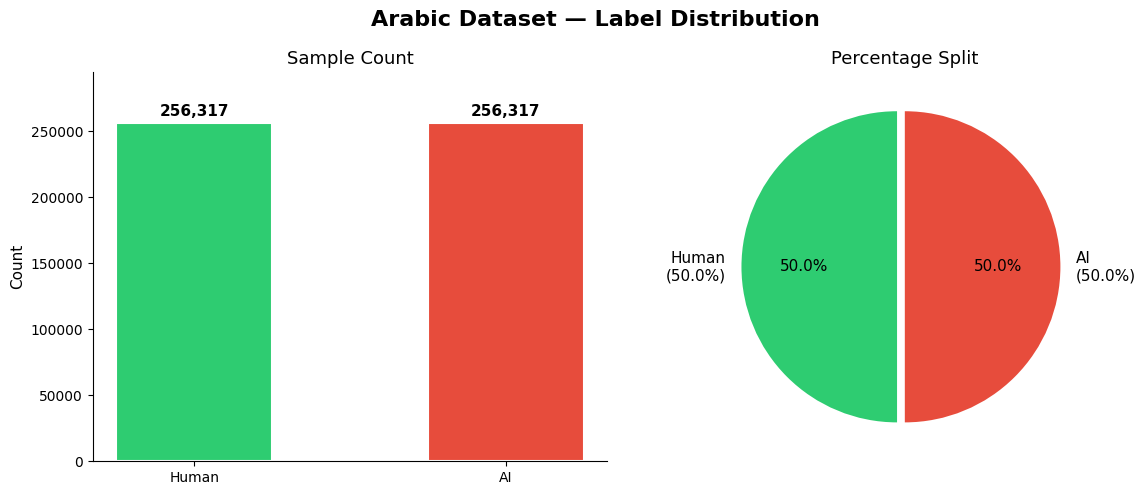

In [35]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Arabic Dataset — Label Distribution', fontsize=16, fontweight='bold')

labels_count = final_dataset['label'].value_counts()
ai_count     = labels_count.get(1, 0)
human_count  = labels_count.get(0, 0)
total        = ai_count + human_count
ai_pct       = (ai_count / total) * 100
human_pct    = (human_count / total) * 100

# Bar Chart
bars = axes[0].bar(
    ['Human', 'AI'],
    [human_count, ai_count],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
axes[0].set_title('Sample Count', fontsize=13)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_ylim(0, max(ai_count, human_count) * 1.15)
for bar, v in zip(bars, [human_count, ai_count]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + total * 0.01,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].spines[['top', 'right']].set_visible(False)

# Pie Chart
axes[1].pie(
    [human_count, ai_count],
    labels=[f'Human\n({human_pct:.1f}%)', f'AI\n({ai_pct:.1f}%)'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0),
    textprops={'fontsize': 11}
)
axes[1].set_title('Percentage Split', fontsize=13)

plt.tight_layout()
plt.savefig('arabic_plot1_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_57/2827305710.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


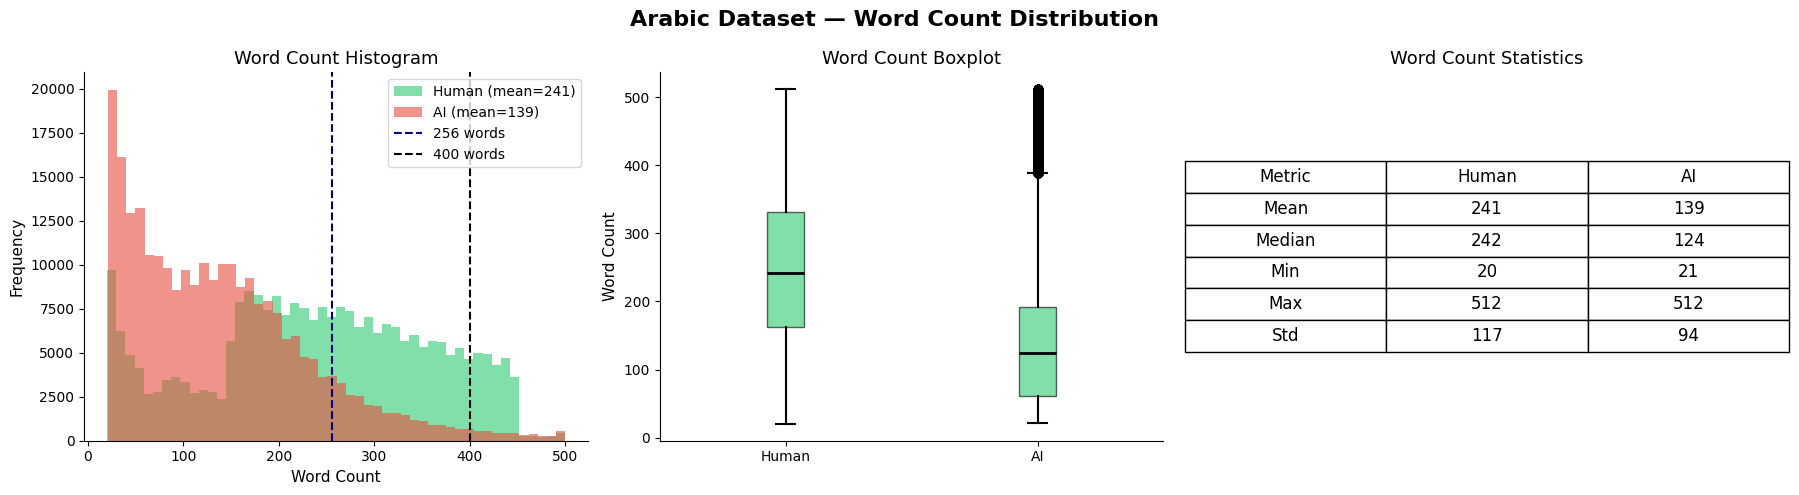

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Arabic Dataset — Word Count Distribution', fontsize=16, fontweight='bold')

final_dataset['word_count'] = final_dataset['text'].str.split().str.len()
human_wc = final_dataset[final_dataset['label'] == 0]['word_count']
ai_wc    = final_dataset[final_dataset['label'] == 1]['word_count']

# Histogram
axes[0].hist(human_wc.clip(upper=500), bins=50, alpha=0.6, color='#2ecc71', label=f'Human (mean={human_wc.mean():.0f})')
axes[0].hist(ai_wc.clip(upper=500),    bins=50, alpha=0.6, color='#e74c3c', label=f'AI (mean={ai_wc.mean():.0f})')
axes[0].axvline(256, color='navy', linestyle='--', linewidth=1.5, label='256 words')
axes[0].axvline(400, color='black', linestyle='--', linewidth=1.5, label='400 words')
axes[0].set_title('Word Count Histogram', fontsize=13)
axes[0].set_xlabel('Word Count', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

# Boxplot
axes[1].boxplot(
    [human_wc.clip(upper=600), ai_wc.clip(upper=600)],
    labels=['Human', 'AI'],
    patch_artist=True,
    boxprops=dict(facecolor='#2ecc71', alpha=0.6),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)
axes[1].set_title('Word Count Boxplot', fontsize=13)
axes[1].set_ylabel('Word Count', fontsize=11)
axes[1].spines[['top', 'right']].set_visible(False)

# Stats Table
stats = final_dataset.groupby('label')['word_count'].describe().round(0)
axes[2].axis('off')
table_data = [
    ['Metric', 'Human', 'AI'],
    ['Mean',   f"{stats.loc[0,'mean']:.0f}",  f"{stats.loc[1,'mean']:.0f}"],
    ['Median', f"{stats.loc[0,'50%']:.0f}",   f"{stats.loc[1,'50%']:.0f}"],
    ['Min',    f"{stats.loc[0,'min']:.0f}",    f"{stats.loc[1,'min']:.0f}"],
    ['Max',    f"{stats.loc[0,'max']:.0f}",    f"{stats.loc[1,'max']:.0f}"],
    ['Std',    f"{stats.loc[0,'std']:.0f}",    f"{stats.loc[1,'std']:.0f}"],
]
table = axes[2].table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)
axes[2].set_title('Word Count Statistics', fontsize=13)

plt.tight_layout()
plt.savefig('arabic_plot2_word_count.png', dpi=150, bbox_inches='tight')
plt.show()

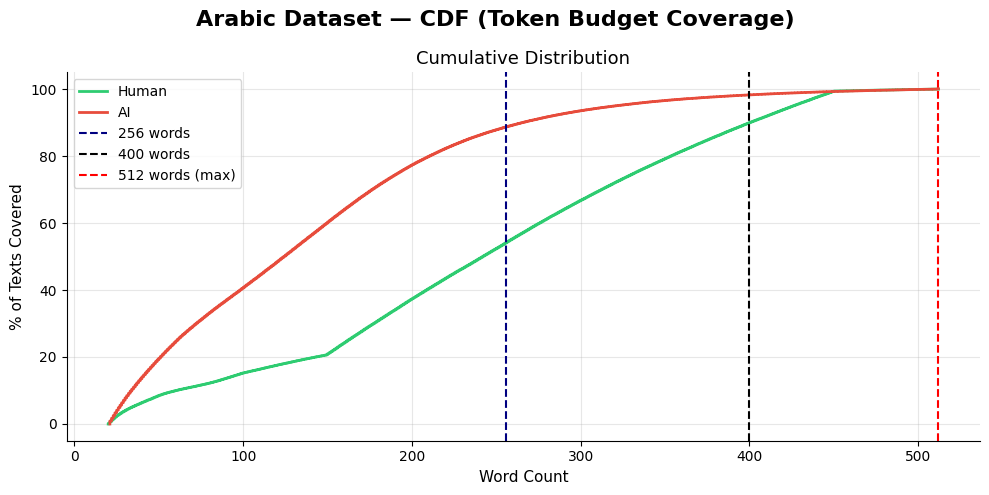

=== Coverage Stats ===

Human:
  < 256 words : 54.0%
  < 400 words : 89.8%
  < 512 words : 100.0%

AI:
  < 256 words : 88.6%
  < 400 words : 98.2%
  < 512 words : 100.0%


In [37]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Arabic Dataset — CDF (Token Budget Coverage)', fontsize=16, fontweight='bold')

for label, color, name in [(0, '#2ecc71', 'Human'), (1, '#e74c3c', 'AI')]:
    subset = final_dataset[final_dataset['label'] == label]['word_count'].sort_values()
    cdf = np.arange(1, len(subset) + 1) / len(subset) * 100
    ax.plot(subset.values, cdf, color=color, label=name, linewidth=2)

ax.axvline(256, color='navy',  linestyle='--', linewidth=1.5, label='256 words')
ax.axvline(400, color='black', linestyle='--', linewidth=1.5, label='400 words')
ax.axvline(512, color='red',   linestyle='--', linewidth=1.5, label='512 words (max)')

ax.set_xlabel('Word Count', fontsize=11)
ax.set_ylabel('% of Texts Covered', fontsize=11)
ax.set_title('Cumulative Distribution', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('arabic_plot3_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Coverage Stats ===")
for label, name in [(0, 'Human'), (1, 'AI')]:
    wc = final_dataset[final_dataset['label'] == label]['word_count']
    print(f"\n{name}:")
    print(f"  < 256 words : {(wc < 256).mean()*100:.1f}%")
    print(f"  < 400 words : {(wc < 400).mean()*100:.1f}%")
    print(f"  < 512 words : {(wc < 512).mean()*100:.1f}%")

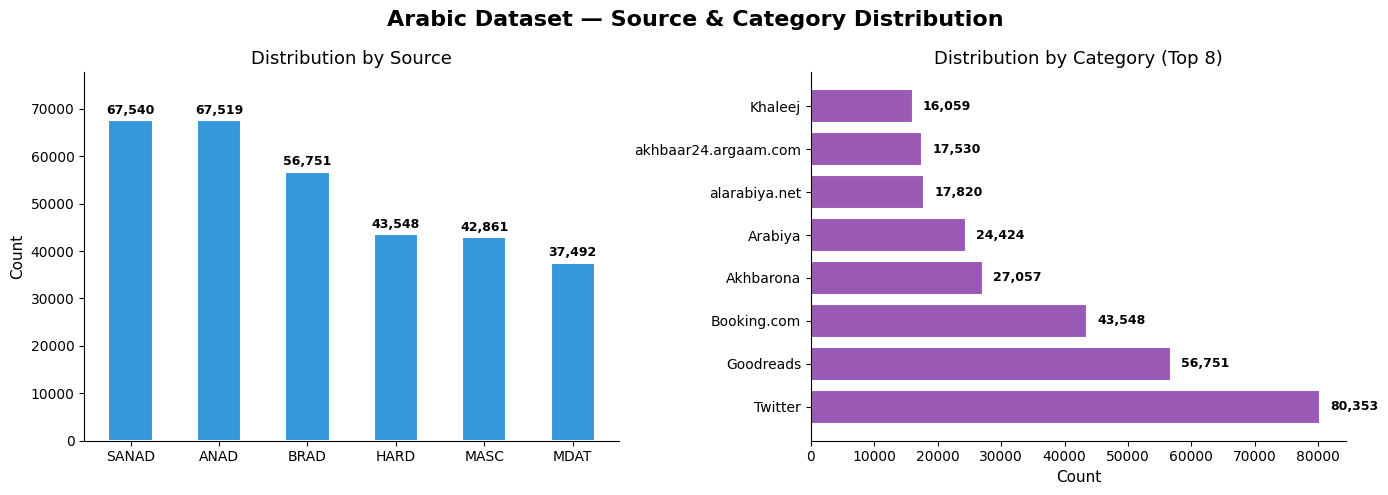

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Arabic Dataset — Source & Category Distribution', fontsize=16, fontweight='bold')

# Source Distribution
source_counts = df['source'].value_counts()
bars = axes[0].bar(
    source_counts.index,
    source_counts.values,
    color='#3498db',
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
axes[0].set_title('Distribution by Source', fontsize=13)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_ylim(0, source_counts.max() * 1.15)
for bar, v in zip(bars, source_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + source_counts.max() * 0.02,
                 f'{v:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# Category Distribution (Top 8)
cat_counts = df['category'].value_counts().head(8)
bars = axes[1].barh(
    cat_counts.index,
    cat_counts.values,
    color='#9b59b6',
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Distribution by Category (Top 8)', fontsize=13)
axes[1].set_xlabel('Count', fontsize=11)
for bar, v in zip(bars, cat_counts.values):
    axes[1].text(v + cat_counts.max() * 0.02,
                 bar.get_y() + bar.get_height()/2,
                 f'{v:,}', va='center', fontsize=9, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('arabic_plot4_source_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# 6. Save the final dataset as CSV
final_dataset.to_csv("arabic_ready1.csv", index=False, encoding='utf-8-sig')

In [41]:
# Clean Function
def clean_text(text):
    # 1. شيل URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 2. شيل Mentions و Hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # 4. شيل newlines و extra spaces
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [42]:
# تنظيف النص
final_dataset['text'] = final_dataset['text'].apply(clean_text)
print(" Text cleaned")

 Text cleaned


In [43]:
# حفظ
final_dataset.to_csv('/kaggle/working/final_arabic_ready.csv', index=False)
print(" Saved: final_arabic_dataset_ready.csv")

 Saved: final_arabic_dataset_ready.csv
